# CLB-581 Ground Truth Hyetograph Validation

This notebook validates hms-commander storm generators against HEC-HMS 4.13 `PRECIP-INC` DSS output for the CLB-581 test matrix. The checked-in CSV fixtures in `tests/fixtures/ground_truth/` are the durable ground truth; the HMS source project and compute logs are preserved under the Symphony artifact directory for review.


In [1]:
# For package users:
# pip install hms-commander[all]

# For source development, run from the repository root with this checkout on PYTHONPATH.
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hms_commander import FrequencyStorm, ScsTypeStorm, HmsExamples

import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("hms_commander").setLevel(logging.WARNING)


def display_path(path, base=None):
    path = Path(path)
    base = Path.cwd() if base is None else Path(base)
    try:
        return path.resolve().relative_to(base.resolve()).as_posix()
    except Exception:
        return path.name


ROOT = Path.cwd()
if not (ROOT / "tests" / "fixtures" / "ground_truth").exists():
    ROOT = ROOT.parent

FIXTURE_DIR = ROOT / "tests" / "fixtures" / "ground_truth"
metadata = json.loads((FIXTURE_DIR / "metadata.json").read_text(encoding="utf-8"))
print(f"Loaded {len(metadata['cases'])} HMS ground-truth cases from {display_path(FIXTURE_DIR)}")
print(metadata["method"])

Loaded 5 HMS ground-truth cases from ground_truth
HMS_Controller JAB Multiple Compute GUI run in HEC-HMS 4.13; PRECIP-INC extracted from output DSS version 2 records


## Phase 1: HMS Fixture Generation

The fixtures were produced from the HEC-HMS Castro sample project. Routine notebook execution validates the checked-in CSV fixtures only. Regeneration should start from a clean `HmsExamples.extract_project("castro", version="4.13", ...)` workspace and then use the documented interactive HMS GUI/JAB workflow for computing the fixture runs.

In [2]:
RUN_HMS_GUI_FIXTURE_GENERATION = False

hms_version = metadata.get("hms_version", "4.13")
regeneration_workspace = ROOT / "example_projects" / "ground_truth_regeneration"
fixture_method = metadata["method"]

phase1_manifest = [
    "Routine notebook execution validates checked-in fixtures only.",
    "For regeneration, extract a clean Castro HMS sample with HmsExamples:",
    f"  HmsExamples.extract_project('castro', version='{hms_version}', output_path=regeneration_workspace, suffix='regeneration')",
    "Enable Java Access Bridge from the selected HEC-HMS installation if GUI automation requires it.",
    "Open the extracted Castro project in HEC-HMS and compute the fixture runs through the interactive GUI workflow.",
    "After the GUI compute completes, extract the DSS version 2 PRECIP-INC records:",
    "  python scripts/generate_ground_truth_fixtures.py --existing-project-dir <extracted-castro-project> --skip-compute --method '<fixture_method>'",
]

if RUN_HMS_GUI_FIXTURE_GENERATION:
    source_project = HmsExamples.extract_project(
        "castro",
        version=hms_version,
        output_path=regeneration_workspace,
        suffix="regeneration",
        overwrite=True,
    )
    raise RuntimeError(
        "Run the printed HMS GUI workflow from an interactive desktop session; "
        f"the regenerated source project is {source_project}."
    )

print("Phase 1 regeneration is skipped for routine notebook execution.")
print("Interactive GUI regeneration manifest:")
for line in phase1_manifest:
    print(line.replace("<fixture_method>", fixture_method))

Phase 1 regeneration is skipped for routine notebook execution.
Interactive GUI regeneration manifest:
Routine notebook execution validates checked-in fixtures only.
For regeneration, extract a clean Castro HMS sample with HmsExamples:
  HmsExamples.extract_project('castro', version='4.13', output_path=regeneration_workspace, suffix='regeneration')
Enable Java Access Bridge from the selected HEC-HMS installation if GUI automation requires it.
Open the extracted Castro project in HEC-HMS and compute the fixture runs through the interactive GUI workflow.
After the GUI compute completes, extract the DSS version 2 PRECIP-INC records:
  python scripts/generate_ground_truth_fixtures.py --existing-project-dir <extracted-castro-project> --skip-compute --method 'HMS_Controller JAB Multiple Compute GUI run in HEC-HMS 4.13; PRECIP-INC extracted from output DSS version 2 records'


## Phase 2: Python Validation

Each Python hyetograph includes the internal zero-depth sentinel at t=0. HEC-HMS `PRECIP-INC` DSS records begin at the first completed interval, so the comparison drops the first Python row and then compares values in order.


In [3]:
CASES = [
    {"test_id": "T01", "fixture": "t01_t01_scs_type_ii_10in_24hr_60min.csv", "total_depth": 10.0, "interval": 60, "scs_type": "II"},
    {"test_id": "T02", "fixture": "t02_t02_scs_type_ii_10in_24hr_5min.csv", "total_depth": 10.0, "interval": 5, "scs_type": "II"},
    {"test_id": "T03", "fixture": "t03_t03_scs_type_i_10in_24hr_60min.csv", "total_depth": 10.0, "interval": 60, "scs_type": "I"},
    {"test_id": "T04", "fixture": "t04_t04_scs_type_iii_10in_24hr_60min.csv", "total_depth": 10.0, "interval": 60, "scs_type": "III"},
    {"test_id": "T05", "fixture": "t05_t05_frequency_tp40_13_20in_24hr_5min.csv", "total_depth": 13.20, "interval": 5, "scs_type": None},
]


def generate_python_values(case):
    if case["scs_type"]:
        generated = ScsTypeStorm.generate_hyetograph(
            total_depth_inches=case["total_depth"],
            scs_type=case["scs_type"],
            time_interval_min=case["interval"],
        )
    else:
        generated = FrequencyStorm.generate_hyetograph(
            total_depth_inches=case["total_depth"],
            total_duration_min=24 * 60,
            time_interval_min=case["interval"],
            peak_position_pct=67.0,
        )
    return generated["incremental_depth"].to_numpy(dtype=float)[1:]

results = []
series = {}
for case in CASES:
    fixture = pd.read_csv(FIXTURE_DIR / case["fixture"])
    hms_values = fixture["hms_precip_inc"].to_numpy(dtype=float)
    python_values = generate_python_values(case)
    diff = python_values - hms_values
    max_abs_diff = float(np.max(np.abs(diff)))
    results.append({
        "test_id": case["test_id"],
        "storm_type": fixture["storm_type"].iloc[0],
        "rows": len(hms_values),
        "hms_total_in": float(hms_values.sum()),
        "python_total_in": float(python_values.sum()),
        "max_abs_diff_in": max_abs_diff,
        "passes_0_0001_in": max_abs_diff < 0.0001,
    })
    series[case["test_id"]] = (fixture, python_values, diff)

summary = pd.DataFrame(results)
display(summary)
assert summary["passes_0_0001_in"].all()


,test_id,storm_type,rows,hms_total_in,python_total_in,max_abs_diff_in,passes_0_0001_in
0,T01,SCS Type II,24,10.000000,10.0,1.970646e-15,True
1,T02,SCS Type II,288,10.000000,10.0,1.915135e-15,True
2,T03,SCS Type I,24,10.000000,10.0,7.216450e-16,True
3,T04,SCS Type III,24,10.000000,10.0,2.275957e-15,True
4,T05,Frequency Storm (TP-40),288,13.199822,13.2,1.619784e-05,True


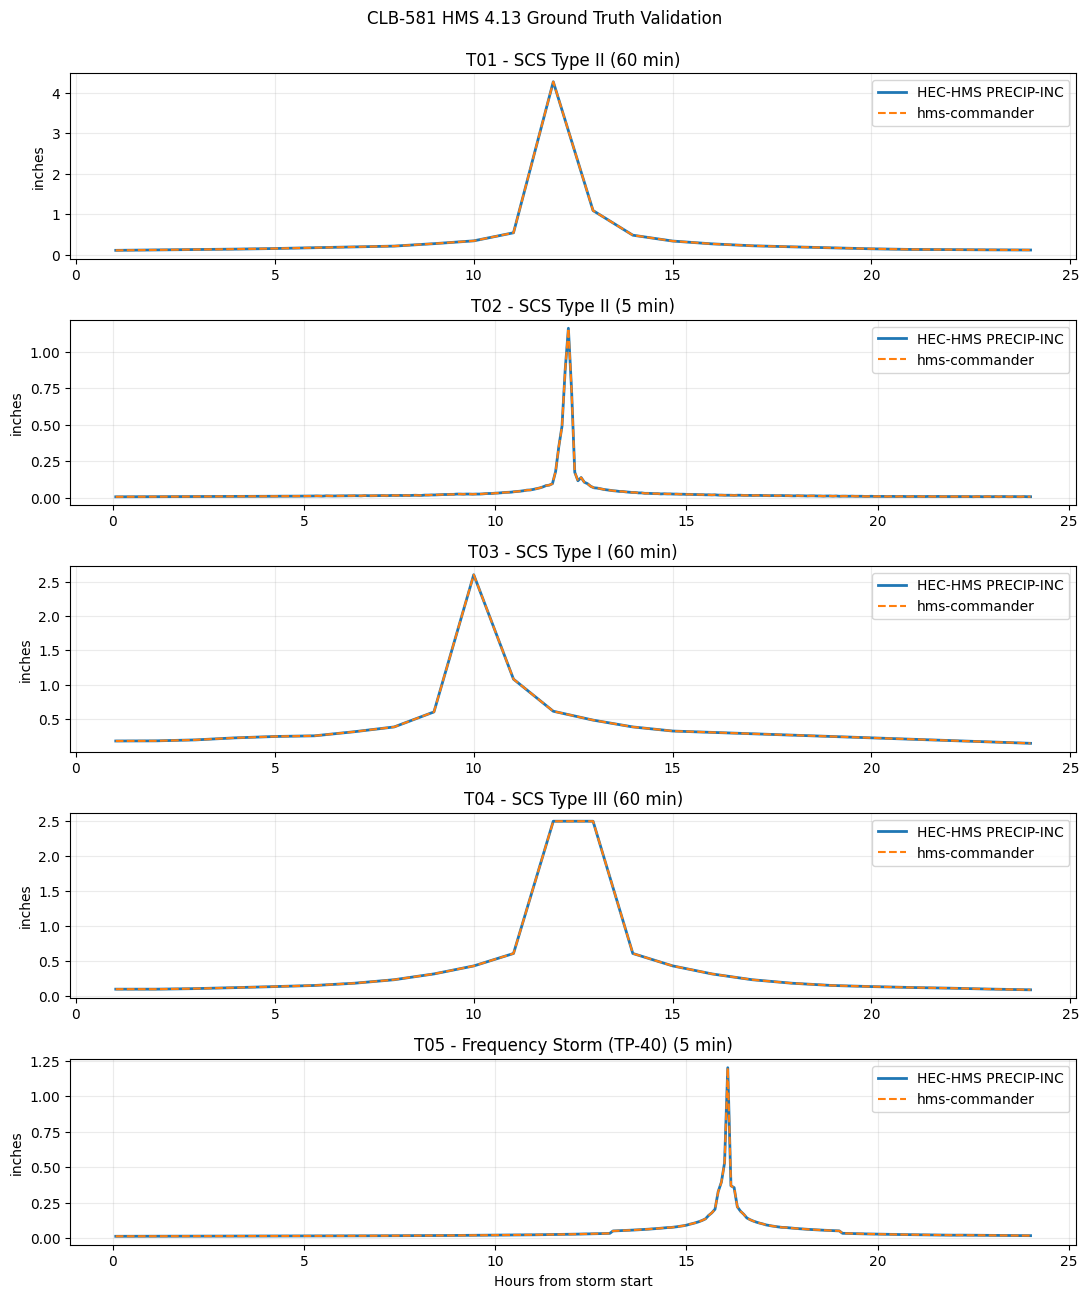

In [4]:
fig, axes = plt.subplots(len(CASES), 1, figsize=(11, 13), sharex=False)
for ax, case in zip(axes, CASES):
    fixture, python_values, diff = series[case["test_id"]]
    hours = fixture["hour"].to_numpy(dtype=float)
    hms_values = fixture["hms_precip_inc"].to_numpy(dtype=float)
    ax.plot(hours, hms_values, label="HEC-HMS PRECIP-INC", linewidth=2)
    ax.plot(hours, python_values, "--", label="hms-commander", linewidth=1.5)
    ax.set_title(f"{case['test_id']} - {fixture['storm_type'].iloc[0]} ({case['interval']} min)")
    ax.set_ylabel("inches")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Hours from storm start")
fig.suptitle("CLB-581 HMS 4.13 Ground Truth Validation", y=0.995)
fig.tight_layout()


In [5]:
frequency_row = summary.loc[summary["test_id"] == "T05"].iloc[0]
print("Root cause notes")
print("SCS Type I/II/III cases match to numerical roundoff after removing the t=0 sentinel.")
print(
    "T05 frequency storm max absolute difference is "
    f"{frequency_row['max_abs_diff_in']:.8f} in; HMS total is "
    f"{frequency_row['hms_total_in']:.9f} in versus Python "
    f"{frequency_row['python_total_in']:.9f} in."
)
print("The T05 difference is consistent with HMS output precision in the frequency-storm increment series and remains below 0.0001 in.")


Root cause notes
SCS Type I/II/III cases match to numerical roundoff after removing the t=0 sentinel.
T05 frequency storm max absolute difference is 0.00001620 in; HMS total is 13.199821813 in versus Python 13.200000000 in.
The T05 difference is consistent with HMS output precision in the frequency-storm increment series and remains below 0.0001 in.
